# Mini Project NLP — CNN1D for NER

Notebook này xây dựng mô hình **Multi-Scale CNN1D** với **Residual Connections** và **Layer Normalization** cho bài toán Named Entity Recognition trên bộ dữ liệu PhoNER_COVID19.

# Import libraries

In [1]:
!pip install -q py_vncorenlp seqeval torchinfo

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.1 MB/s eta 0:00:00


In [2]:
import os
import random
import unicodedata

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import py_vncorenlp
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback
)

from seqeval.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

from torchinfo import summary

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SEED = 42

def set_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

Using device: cuda


# Download dataset

In [4]:
# "word" là bản đã được segment từ ví dụ "lịch sử" -> "lịch_sử"
dataset = load_dataset("phucdev/PhoNER_COVID19", "word")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

word/train-00000-of-00001.parquet:   0%|          | 0.00/366k [00:00<?, ?B/s]

word/validation-00000-of-00001.parquet:   0%|          | 0.00/160k [00:00<?, ?B/s]

word/test-00000-of-00001.parquet:   0%|          | 0.00/247k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5027 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
print(dataset['train'][:5])

{'words': [['Đồng_thời', ',', 'bệnh_viện', 'tiếp_tục', 'thực_hiện', 'các', 'biện_pháp', 'phòng_chống', 'dịch_bệnh', 'COVID', '-', '19', 'theo', 'hướng_dẫn', 'của', 'Bộ', 'Y_tế', '.'], ['"', 'Số', 'bệnh_viện', 'có_thể', 'tiếp_nhận', 'bệnh_nhân', 'bị', 'sốt', 'cao', 'và', 'khó', 'thở', 'đang', 'giảm', 'dần', '"', ',', 'thông_cáo', 'có', 'đoạn', ',', 'cảnh_báo', 'những', 'bệnh_nhân', 'này', 'thay', 'vào', 'đó', 'được', 'chuyển', 'tới', 'các', 'phòng_khám', 'khẩn_cấp', ',', 'khiến', 'những', 'bệnh_nhân', 'mắc', 'bệnh', 'hiểm_nghèo', 'khác', 'không', 'có', 'cơ_hội', 'được', 'điều_trị', '.'], ['Ngoài_ra', ',', 'những', 'người', 'tiếp_xúc', 'gián_tiếp', '(', 'đã', 'gặp', 'những', 'người', 'tiếp_xúc', 'gần', 'với', 'bệnh_nhân', ')', 'được', 'lập', 'danh_sách', 'và', 'yêu_cầu', 'cách_ly', 'y_tế', 'tại', 'nơi', 'ở', '.'], ['Bà', 'này', 'khi', 'trở', 'về', 'quá_cảnh', 'Doha', '(', 'Qatar', ')', ',', 'đáp', 'xuống', 'Tân_Sơn_Nhất', 'sáng', '2/3', 'cùng', '75', 'hành_khách', ',', 'trong', 'đó', 'có

# Load tokenizer & rdrsegmenter

In [5]:
save_dir = os.path.abspath('/content/VnCoreNLP')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    py_vncorenlp.download_model(save_dir=save_dir)

rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir='/content/VnCoreNLP')
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=True)

!cd /content/

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

# Preprocess data

In [6]:
# Bộ dataset cần ép về chuẩn NFC để tokenizers mới không bị lỗi
def preprocess_for_phobert(word_list):
    cleaned_words = [unicodedata.normalize('NFC', w) for w in word_list]
    return cleaned_words

clean_dataset = dataset.map(
    lambda x: {'words': preprocess_for_phobert(x['words'])},
    num_proc=2
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

# Measure dataset length

In [7]:
def get_length(examples):
    return {
        "length": [len(ids) for ids in examples["words"]]
    }

length_dataset = clean_dataset.map(
    get_length,
    batched=True,
    num_proc=2,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

--- Statistics for train ---
Mean: 26.36 | Max: 161 | p95: 50 | p99: 65

--- Statistics for validation ---
Mean: 28.14 | Max: 138 | p95: 54 | p99: 72

--- Statistics for test ---
Mean: 28.56 | Max: 162 | p95: 55 | p99: 72



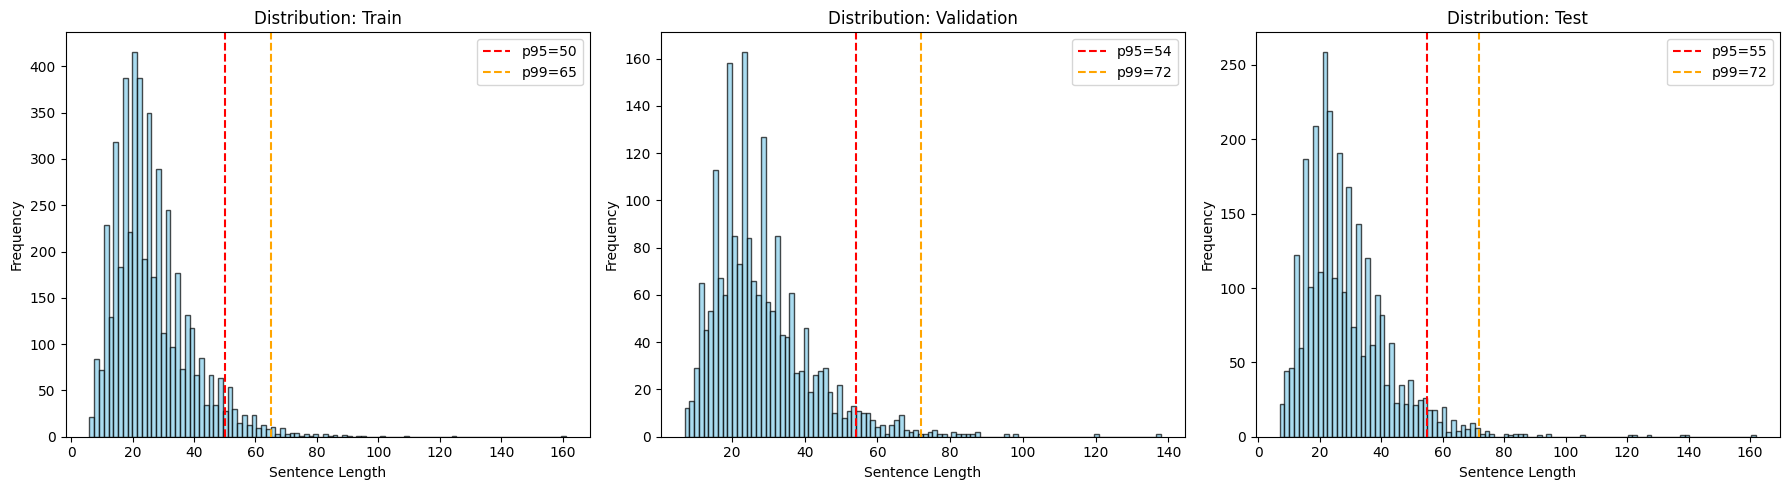

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
dataset_stats = {}
splits = ["train", "validation", "test"]

# Thiết lập figure cho plotting (1 hàng, 3 cột)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, split in enumerate(splits):
    # 1. Trích xuất độ dài
    lengths = np.array(length_dataset[split]["length"])

    # 2. Tính toán các chỉ số
    p95 = int(np.percentile(lengths, 95))
    p99 = int(np.percentile(lengths, 99))
    max_val = int(lengths.max())
    mean_val = lengths.mean()

    # 3. Lưu vào dictionary
    dataset_stats[split] = {
        "p95": p95,
        "p99": p99,
        "max_len": max_val,
        "mean": mean_val
    }

    # 4. In thông tin ra màn hình
    print(f"--- Statistics for {split} ---")
    print(f"Mean: {mean_val:.2f} | Max: {max_val} | p95: {p95} | p99: {p99}\n")

    # 5. Vẽ biểu đồ histogram lên subplot tương ứng
    axes[i].hist(lengths, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(p95, color='red', linestyle='--', label=f'p95={p95}')
    axes[i].axvline(p99, color='orange', linestyle='--', label=f'p99={p99}')

    axes[i].set_title(f'Distribution: {split.capitalize()}')
    axes[i].set_xlabel('Sentence Length')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()

# Lưu ảnh lại
plt.savefig('dataset_distribution.png')
plt.show()

# Tải ảnh về máy
from google.colab import files
files.download('dataset_distribution.png')

# Tokenize dataset

In [ ]:
unique_tags = set()
for tags in clean_dataset['train']['tags']:
    unique_tags.update(tags)

unique_tags = sorted(list(unique_tags))

# Sử dụng IGNORE_INDEX chuẩn là -100 thay vì thêm nhãn PAD vào vocab
label2idx = {tag: i for i, tag in enumerate(unique_tags)}
idx2label = {i: tag for i, tag in enumerate(unique_tags)}

IGNORE_INDEX = -100

print(f"Số lượng nhãn thực tế: {len(unique_tags)}")
print("IGNORE_INDEX:", IGNORE_INDEX)
print("label2idx:", label2idx)

Số lượng nhãn thực tế: 20
IGNORE_INDEX: -100
label2idx: {'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-JOB': 12, 'I-LOCATION': 13, 'I-NAME': 14, 'I-ORGANIZATION': 15, 'I-PATIENT_ID': 16, 'I-SYMPTOM_AND_DISEASE': 17, 'I-TRANSPORTATION': 18, 'O': 19}


In [ ]:
# Do PhoBERT sử dụng kĩ thuật bpe do đó ta phải chỉnh lại label cho chính xác
def tokenize_and_align_labels(examples, max_length=72):
    all_input_ids = []
    all_labels = []
    all_attention_masks = []

    cls_token_id = tokenizer.cls_token_id   # PhoBERT: <s>
    sep_token_id = tokenizer.sep_token_id   # PhoBERT: </s>

    for words, tags in zip(examples["words"], examples["tags"]):
        body_input_ids = []
        body_label_ids = []

        for word, tag in zip(words, tags):
            word_piece_ids = tokenizer.encode(word, add_special_tokens=False)
            if len(word_piece_ids) == 0:
                unk_id = tokenizer.unk_token_id
                word_piece_ids = [unk_id]

            body_input_ids.extend(word_piece_ids)
            body_label_ids.append(label2idx[tag])

            if len(word_piece_ids) > 1:
                body_label_ids.extend([IGNORE_INDEX] * (len(word_piece_ids) - 1))

        # Ghép đặc biệt và cắt/truncate 72
        input_ids = [cls_token_id] + body_input_ids + [sep_token_id]
        labels = [IGNORE_INDEX] + body_label_ids + [IGNORE_INDEX]

        if len(input_ids) > max_length:
            input_ids = input_ids[:max_length]
            labels = labels[:max_length]

        attention_mask = [1] * len(input_ids)

        all_input_ids.append(input_ids)
        all_labels.append(labels)
        all_attention_masks.append(attention_mask)

    return {
        "input_ids": all_input_ids,
        "labels": all_labels,
        "attention_mask": all_attention_masks,
    }

tokenized_dataset = clean_dataset.map(
    tokenize_and_align_labels,
    num_proc=2,
    batched=True,
    remove_columns=['words', 'tags']
)

Map (num_proc=2):   0%|          | 0/5027 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/3000 [00:00<?, ? examples/s]

In [ ]:
train_dataset = tokenized_dataset["train"]
eval_dataset = tokenized_dataset["validation"]
test_dataset = tokenized_dataset["test"]

# Utils

In [ ]:
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=IGNORE_INDEX
)

In [ ]:
# Sử dụng hàm này để tránh cho shape của train_loss, eval_loss lệch nhau dẫn tới
# vẽ biểu đồ không chính xác

def plot_loss_curves(history, title='Training and Validation Loss'):
    # Keep only full-epoch logs to align train/eval points cleanly.
    train_epoch_loss = {}
    eval_epoch_loss = {}

    for log in history:
        epoch = log.get('epoch')
        if epoch is None:
            continue

        epoch_float = float(epoch)
        epoch_int = int(round(epoch_float))

        if epoch_int < 1 or abs(epoch_float - epoch_int) > 1e-8:
            continue

        if 'loss' in log and 'eval_loss' not in log:
            train_epoch_loss[epoch_int] = log['loss']
        if 'eval_loss' in log:
            eval_epoch_loss[epoch_int] = log['eval_loss']

    epochs = sorted(set(train_epoch_loss.keys()) & set(eval_epoch_loss.keys()))
    train_loss = [train_epoch_loss[e] for e in epochs]
    eval_loss = [eval_epoch_loss[e] for e in epochs]

    if not epochs:
        raise ValueError('No aligned full-epoch train/eval loss points were found in trainer.state.log_history.')

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, eval_loss, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def labels_from_predictions(predictions, labels):
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [idx2label[p] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    true_labels = [
        [idx2label[l] for (p, l) in zip(prediction, label) if l != IGNORE_INDEX]
        for prediction, label in zip(predictions, labels)
    ]

    return true_labels, true_predictions

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    return {
        "f1": f1_score(true_labels, true_predictions),
    }

In [ ]:
def evaluate_model(trainer, eval_dataset, split_name='test'):
    predictions, labels, metrics = trainer.predict(eval_dataset)
    true_labels, true_predictions = labels_from_predictions(predictions, labels)

    accuracy = accuracy_score(true_labels, true_predictions)
    precision = precision_score(true_labels, true_predictions)
    recall = recall_score(true_labels, true_predictions)
    f1 = f1_score(true_labels, true_predictions)

    print(f"Evaluation on {split_name} set")
    print("Classification Report (Excluded PAD):")
    print(classification_report(true_labels, true_predictions))

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Model

## Model definition

1. **Multi-Scale CNN1D**: Sử dụng 3 nhánh convolution song song với kernel sizes khác nhau (3, 5, 7) để bắt n-gram ở nhiều mức độ ngữ cảnh khác nhau.
2. **Residual Connections**: Giúp gradient lan truyền tốt hơn khi xếp chồng nhiều tầng CNN, tránh vanishing gradient.
3. **Layer Normalization**: Ổn định quá trình huấn luyện hơn Batch Normalization, đặc biệt với câu có chiều dài biến đổi.
4. **Kaiming Weight Initialization**: Khởi tạo trọng số theo He initialization, tối ưu cho hàm kích hoạt GELU.
5. **GELU Activation**: Hàm kích hoạt mượt hơn ReLU, được sử dụng rộng rãi trong các mô hình NLP hiện đại (BERT, GPT).
6. **EarlyStoppingCallback**: Dừng sớm khi mô hình không cải thiện, tiết kiệm thời gian và tránh overfitting.

In [ ]:
class CNN1DResidualBlock(nn.Module):
    """
    Khối CNN1D có Residual Connection.
    Mỗi khối gồm: Conv1D -> LayerNorm -> GELU -> Dropout -> Conv1D -> LayerNorm -> Residual Add -> GELU
    """
    def __init__(self, channels, kernel_size, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2  # same padding để giữ nguyên chiều dài chuỗi
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.GELU()

    def forward(self, x):
        # x shape: [Batch, Channels, Seq_Len]
        residual = x

        out = self.conv1(x)
        out = out.transpose(1, 2)  # -> [B, Seq, C] cho LayerNorm
        out = self.norm1(out)
        out = out.transpose(1, 2)  # -> [B, C, Seq]
        out = self.act(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = out.transpose(1, 2)
        out = self.norm2(out)
        out = out.transpose(1, 2)

        out = out + residual  # Residual connection
        out = self.act(out)
        return out


'''
class MultiScaleCNN1DModel(nn.Module):
    """
    Mô hình CNN1D đa tầng cho NER.

    Kiến trúc:
    - Embedding Layer
    - 3 nhánh CNN song song với kernel_size = 3, 5, 7 (Multi-Scale)
    - Mỗi nhánh có N khối Residual Block xếp chồng
    - Concat 3 nhánh -> Projection -> Classification Head

    Việc dùng nhiều kernel khác nhau cho phép mô hình đồng thời
    nắm bắt ngữ cảnh cục bộ (trigram) lẫn rộng hơn (7-gram).
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 pad_idx, num_blocks=2, kernel_sizes=(3, 5, 7), dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embed_proj = nn.Linear(embedding_dim, hidden_dim)
        self.embed_norm = nn.LayerNorm(hidden_dim)
        self.embed_dropout = nn.Dropout(dropout)

        # Tạo nhiều nhánh CNN song song, mỗi nhánh có kernel_size khác nhau
        self.branches = nn.ModuleList()
        for ks in kernel_sizes:
            branch = nn.Sequential(
                *[CNN1DResidualBlock(hidden_dim, ks, dropout) for _ in range(num_blocks)]
            )
            self.branches.append(branch)

        # Projection layer: gộp 3 nhánh lại (hidden_dim * 3) -> hidden_dim
        self.fusion = nn.Linear(hidden_dim * len(kernel_sizes), hidden_dim)
        self.fusion_norm = nn.LayerNorm(hidden_dim)
        self.fusion_dropout = nn.Dropout(dropout)

        # Classification Head
        self.classifier = nn.Linear(hidden_dim, output_dim)

        self.pad_idx = pad_idx
        self.output_dim = output_dim

        # Khởi tạo trọng số theo Kaiming (He) initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0, std=0.02)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # 1. Embedding + Projection: [B, Seq] -> [B, Seq, hidden_dim]
        x = self.embedding(input_ids)
        x = self.embed_proj(x)
        x = self.embed_norm(x)
        x = self.embed_dropout(x)
        x = F.gelu(x)

        # 2. Chuyển sang dạng [B, C, Seq] cho Conv1d
        x = x.transpose(1, 2)

        # 3. Multi-Scale CNN: chạy song song 3 nhánh rồi concat
        branch_outputs = [branch(x) for branch in self.branches]
        x = torch.cat(branch_outputs, dim=1)  # [B, hidden*3, Seq]

        # 4. Chuyển lại [B, Seq, hidden*3] -> Fusion -> [B, Seq, hidden]
        x = x.transpose(1, 2)
        x = self.fusion(x)
        x = self.fusion_norm(x)
        x = self.fusion_dropout(x)
        x = F.gelu(x)

        # 5. Classification Head: [B, Seq, hidden] -> [B, Seq, Num_Labels]
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(
                logits.view(-1, self.output_dim),
                labels.view(-1),
                ignore_index=self.pad_idx
            )

        return {"loss": loss, "logits": logits}

'''

'\nclass MultiScaleCNN1DModel(nn.Module):\n    """\n    Mô hình CNN1D đa tầng cho NER.\n\n    Kiến trúc:\n    - Embedding Layer\n    - 3 nhánh CNN song song với kernel_size = 3, 5, 7 (Multi-Scale)\n    - Mỗi nhánh có N khối Residual Block xếp chồng\n    - Concat 3 nhánh -> Projection -> Classification Head\n\n    Việc dùng nhiều kernel khác nhau cho phép mô hình đồng thời\n    nắm bắt ngữ cảnh cục bộ (trigram) lẫn rộng hơn (7-gram).\n    """\n    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,\n                 pad_idx, num_blocks=2, kernel_sizes=(3, 5, 7), dropout=0.1):\n        super().__init__()\n        self.embedding = nn.Embedding(vocab_size, embedding_dim)\n        self.embed_proj = nn.Linear(embedding_dim, hidden_dim)\n        self.embed_norm = nn.LayerNorm(hidden_dim)\n        self.embed_dropout = nn.Dropout(dropout)\n\n        # Tạo nhiều nhánh CNN song song, mỗi nhánh có kernel_size khác nhau\n        self.branches = nn.ModuleList()\n        for ks in k

In [ ]:
from transformers import PretrainedConfig

class SwiGLU(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.w1 = nn.Linear(in_features, out_features)
        self.w2 = nn.Linear(in_features, out_features)

    def forward(self, x):
        return F.silu(self.w1(x)) * self.w2(x)

class MultiScaleCNN1DModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 pad_idx, num_blocks=2, kernel_sizes=(3, 5, 7), dropout=0.1):
        super().__init__()
        # Sử dụng PretrainedConfig thay vì dict để Trainer không bị lỗi
        self.config = PretrainedConfig(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=hidden_dim,
            output_dim=output_dim,
            pad_idx=pad_idx,
            num_blocks=num_blocks,
            kernel_sizes=kernel_sizes,
            dropout=dropout
        )

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embed_proj = nn.Linear(embedding_dim, hidden_dim)
        self.embed_norm = nn.LayerNorm(hidden_dim)
        self.embed_dropout = nn.Dropout(dropout)

        self.branches = nn.ModuleList()
        for ks in kernel_sizes:
            branch = nn.Sequential(
                *[CNN1DResidualBlock(hidden_dim, ks, dropout) for _ in range(num_blocks)]
            )
            self.branches.append(branch)

        self.swiglu = SwiGLU(hidden_dim * len(kernel_sizes), hidden_dim)
        self.fusion_norm = nn.LayerNorm(hidden_dim)
        self.fusion_dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(hidden_dim, output_dim)
        self.pad_idx = pad_idx
        self.output_dim = output_dim
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0, std=0.02)

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        x = self.embedding(input_ids)
        x = F.gelu(self.embed_norm(self.embed_proj(x)))
        x = self.embed_dropout(x).transpose(1, 2)

        branch_outputs = [branch(x) for branch in self.branches]
        x = torch.cat(branch_outputs, dim=1).transpose(1, 2)

        x = self.swiglu(x)
        x = self.fusion_norm(x)
        x = self.fusion_dropout(x)
        logits = self.classifier(F.gelu(x))

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.view(-1, self.output_dim), labels.view(-1), ignore_index=self.pad_idx)
        return {"loss": loss, "logits": logits}

## Model instantiation & Summary

In [ ]:
cnn_model = MultiScaleCNN1DModel(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=256,
    hidden_dim=256,
    output_dim=len(unique_tags),
    pad_idx=IGNORE_INDEX,
    num_blocks=2,
    kernel_sizes=(3, 5, 7),
    dropout=0.15
)

summary(cnn_model, input_size=(1, 10), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
MultiScaleCNN1DModel                     [1, 10, 20]               --
├─Embedding: 1-1                         [1, 10, 256]              16,384,000
├─Linear: 1-2                            [1, 10, 256]              65,792
├─LayerNorm: 1-3                         [1, 10, 256]              512
├─Dropout: 1-4                           [1, 10, 256]              --
├─ModuleList: 1-5                        --                        --
│    └─Sequential: 2-1                   [1, 256, 10]              --
│    │    └─CNN1DResidualBlock: 3-1      [1, 256, 10]              394,752
│    │    └─CNN1DResidualBlock: 3-2      [1, 256, 10]              394,752
│    └─Sequential: 2-2                   [1, 256, 10]              --
│    │    └─CNN1DResidualBlock: 3-3      [1, 256, 10]              656,896
│    │    └─CNN1DResidualBlock: 3-4      [1, 256, 10]              656,896
│    └─Sequential: 2-3                   [1, 256, 10

## Training

**Cải tiến Training:**
- `warmup_ratio=0.05`: Tăng learning rate từ từ trong 5% số bước đầu để ổn định.
- `lr_scheduler_type='cosine'`: Giảm learning rate theo cosine thay vì tuyến tính, giúp hội tụ mượt hơn.
- `weight_decay=0.01`: L2 regularization chống overfitting.
- `EarlyStoppingCallback(patience=10)`: Dừng sớm nếu F1 không cải thiện sau 10 epochs liên tiếp.
- `save_total_limit=3`: Chỉ giữ lại 3 checkpoint gần nhất để tiết kiệm ổ đĩa.
- `fp16=True`: Mixed precision training giúp tăng tốc trên GPU.

In [ ]:
training_args = TrainingArguments(
    output_dir='/content/cnn1d_ner',
    num_train_epochs=100,
    optim="adamw_torch",
    learning_rate=5e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type='cosine',
    per_device_train_batch_size=512,
    per_device_eval_batch_size=512,

    logging_strategy='epoch',
    logging_first_step=True,
    eval_strategy='epoch',
    save_strategy='epoch',

    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    save_total_limit=3,
    fp16=True,
)

trainer = Trainer(
    model=cnn_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)],
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
train_result = trainer.train()
print('Train result:', train_result)

Epoch,Training Loss,Validation Loss,F1
1,2.778235,1.435826,0.000000
2,1.159419,0.986097,0.001850
3,0.773382,0.618782,0.314048
4,0.399659,0.321906,0.692630
5,0.198329,0.223446,0.771719
6,0.117062,0.179887,0.822550
7,0.080891,0.167328,0.839987
8,0.060055,0.150745,0.859140
9,0.047884,0.157404,0.866653
10,0.038912,0.152176,0.874187


Train result: TrainOutput(global_step=490, training_loss=0.12228083914449933, metrics={'train_runtime': 248.6677, 'train_samples_per_second': 2021.574, 'train_steps_per_second': 4.021, 'total_flos': 0.0, 'train_loss': 0.12228083914449933, 'epoch': 49.0})


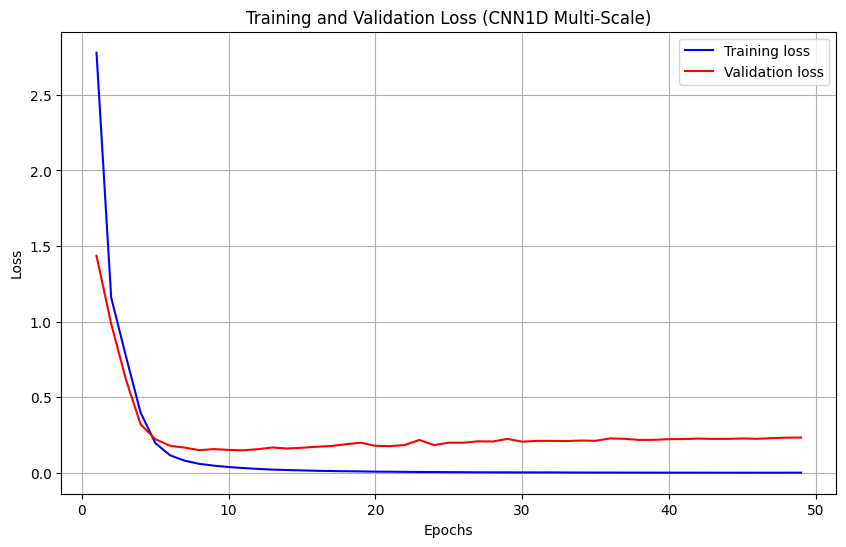

In [ ]:
history = trainer.state.log_history
plot_loss_curves(history, title='Training and Validation Loss (CNN1D Multi-Scale)')

## Evaluate

In [ ]:
cnn_result = evaluate_model(trainer, tokenized_dataset["test"], split_name='test')

Evaluation on test set
Classification Report (Excluded PAD):
                     precision    recall  f1-score   support

                AGE       0.93      0.95      0.94       567
               DATE       0.95      0.97      0.96      1644
             GENDER       0.92      0.94      0.93       448
                JOB       0.57      0.51      0.54       173
           LOCATION       0.85      0.88      0.86      4408
               NAME       0.90      0.81      0.85       314
       ORGANIZATION       0.73      0.74      0.74       770
         PATIENT_ID       0.96      0.96      0.96      1965
SYMPTOM_AND_DISEASE       0.79      0.75      0.77      1127
     TRANSPORTATION       0.93      0.87      0.90       193

          micro avg       0.87      0.88      0.88     11609
          macro avg       0.85      0.84      0.84     11609
       weighted avg       0.87      0.88      0.88     11609

Accuracy: 0.9621
Precision: 0.8746
Recall: 0.8822
F1 Score: 0.8784


## Save model weight

In [ ]:
# save model
trainer.save_model('/content/cnn1d_ner_final')

In [ ]:
import json
import os
import torch
from safetensors.torch import save_file
import matplotlib.pyplot as plt

def save_project_artifacts(model, trainer, metrics, history, folder_name='cnn1d_multi_scale'):
    os.makedirs(folder_name, exist_ok=True)

    # 1. Save model weights
    save_file(model.state_dict(), os.path.join(folder_name, 'model.safetensors'))

    # 2. Custom model_config.json
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    final_config = {
        "model_type": "MultiScaleCNN1D_SwiGLU",
        "vocab_size": int(model.config.vocab_size),
        "embedding_dim": int(model.config.embedding_dim),
        "hidden_dim": int(model.config.hidden_dim),
        "output_dim": int(model.config.output_dim),
        "num_blocks": int(model.config.num_blocks),
        "kernel_sizes": list(model.config.kernel_sizes),
        "dropout": float(model.config.dropout),
        "ignore_index": int(model.config.pad_idx),
        "total_params": int(total_params),
        "trainable_params": int(trainable_params)
    }

    config_path = os.path.join(folder_name, "model_config.json")
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(final_config, f, ensure_ascii=False, indent=4)

    # 3. Save result.json
    with open(os.path.join(folder_name, 'result.json'), 'w') as f:
        json.dump(metrics, f, indent=4)

    # 4. Save loss curve
    plt.figure(figsize=(10, 6))
    train_losses = [log['loss'] for log in history if 'loss' in log]
    eval_losses = [log['eval_loss'] for log in history if 'eval_loss' in log]

    if train_losses: plt.plot(train_losses, label='Train Loss')
    if eval_losses: plt.plot(eval_losses, label='Eval Loss')

    plt.title('Training and Validation Loss')
    plt.xlabel('Logging Steps/Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(folder_name, 'loss_curve.png'))
    plt.close()

    print(f"All artifacts saved to: {folder_name}/")

# Thực hiện lưu toàn bộ kết quả
save_project_artifacts(
    model=cnn_model,
    trainer=trainer,
    metrics=cnn_result,
    history=trainer.state.log_history
)

All artifacts saved to: cnn1d_multi_scale/


In [ ]:
import os
from google.colab import files

# Xác định đường dẫn thư mục (đã xác nhận tồn tại ở bước trước)
folder_path = 'cnn1d_multi_scale'
zip_path = '/content/cnn1d_multi_scale.zip'

# Nén thư mục thành file zip sử dụng đường dẫn tương đối
!zip -r {zip_path} {folder_path}

# Tải file về máy
if os.path.exists(zip_path):
    files.download(zip_path)
else:
    print(f'Không tìm thấy tệp {zip_path} để tải về.')

  adding: cnn1d_multi_scale/ (stored 0%)
  adding: cnn1d_multi_scale/result.json (deflated 29%)
  adding: cnn1d_multi_scale/model_config.json (deflated 42%)
  adding: cnn1d_multi_scale/loss_curve.png (deflated 13%)
  adding: cnn1d_multi_scale/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>